# Notebook 04 — Model Validation

Applies credit-risk-specific validation metrics to the trained models.

| Metric | Why it matters |
|---|---|
| KS Statistic | Standard credit scorecard discrimination metric used at banks alongside ROC-AUC |
| PSI | Detects score distribution drift between training and test windows |
| Threshold Analysis | Business cost (FP vs FN) at each decision cutoff |
| SHAP | Feature importance — explains *which* borrower characteristics drive predictions |

In [9]:
import sys, pickle
sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.metrics import roc_auc_score, r2_score
from src.evaluation import ks_statistic, plot_ks_curve, psi, threshold_analysis_table, shap_analysis
from src.preprocessing import NUMERICAL_FEATURES, CATEGORICAL_FEATURES
plt.rcParams['figure.dpi'] = 120

with open('../models/last_window_artifacts.pkl', 'rb') as f:
    art = pickle.load(f)

xgb_best   = art['xgb_best']
ridge_best = art['ridge_best']
preprocessor = art['preprocessor']
X_tr_t = art['X_tr_t'];  X_te_t = art['X_te_t']
y_def_tr = art['y_def_tr']; y_def_te = art['y_def_te']
y_ret_tr = art['y_ret_tr']; y_ret_te = art['y_ret_te']
y_prob_xgb_tr = art['y_prob_xgb_tr']
y_prob_xgb_te = art['y_prob_xgb_te']
best_thresh   = art['best_thresh_xgb']

X_tr_dense = X_tr_t.toarray() if hasattr(X_tr_t, 'toarray') else X_tr_t
X_te_dense = X_te_t.toarray() if hasattr(X_te_t, 'toarray') else X_te_t

available_num = NUMERICAL_FEATURES
available_cat = CATEGORICAL_FEATURES
cat_names = preprocessor.named_transformers_['cat'].get_feature_names_out(available_cat)
feature_names = list(available_num) + list(cat_names)
print(f'Test set: {len(y_def_te):,} loans | Default rate: {y_def_te.mean():.2%}')

Test set: 282,138 loans | Default rate: 5.20%


---
## 1. KS Statistic

The KS stat is the **primary credit scorecard discrimination metric** at banks. A KS > 0.20 is generally considered acceptable; > 0.40 is strong.

KS Statistic  : 0.1887
p-value       : 0.0
Interpretation: Weak (KS < 0.20)


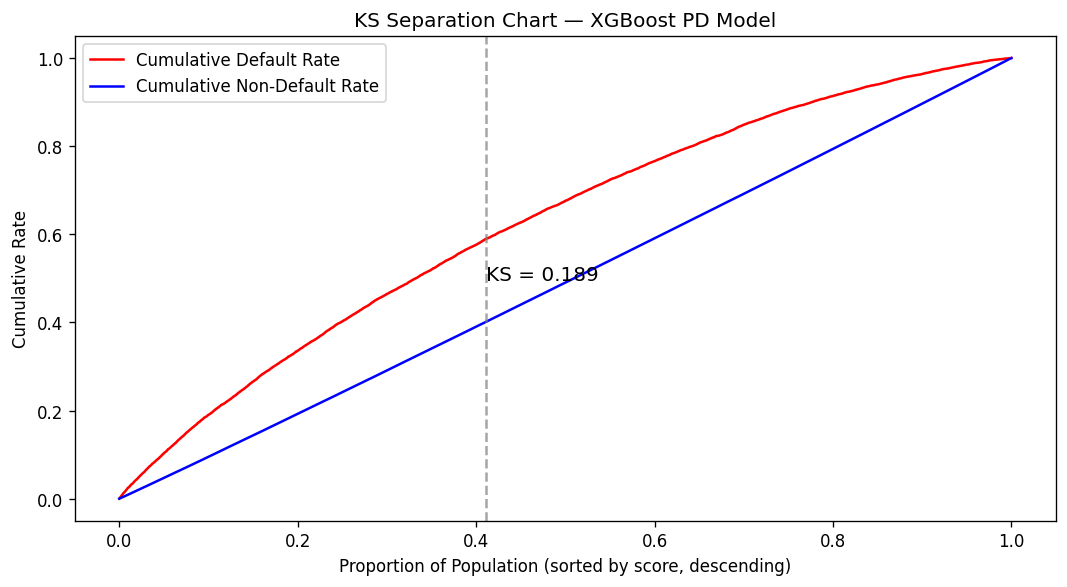

In [10]:
ks_result = ks_statistic(y_def_te, y_prob_xgb_te)
print(f"KS Statistic  : {ks_result['ks_stat']}")
print(f"p-value       : {ks_result['ks_pvalue']}")
print(f"Interpretation: {ks_result['interpretation']}")
fig = plot_ks_curve(y_def_te, y_prob_xgb_te, model_name='XGBoost PD Model')
plt.show()

---
## 2. Population Stability Index (PSI)

PSI detects score distribution drift. PSI < 0.10 = stable; 0.10–0.25 = investigate; ≥ 0.25 = rebuild.

PSI = 0.0256  →  Stable (PSI < 0.10)


,Bin,Expected %,Actual %,Bin PSI
0,0.0–0.1,89.71,88.79,0.0001
1,0.1–0.2,6.04,7.55,0.0034
2,0.2–0.3,1.54,2.17,0.0021
3,0.3–0.4,0.72,0.85,0.0002
4,0.4–0.5,0.64,0.35,0.0017
5,0.5–0.6,0.57,0.17,0.0049
6,0.6–0.7,0.40,0.08,0.0053
7,0.7–0.8,0.28,0.03,0.0059
8,0.8–0.9,0.10,0.01,0.0020
9,0.9–1.0,0.01,0.01,0.0000


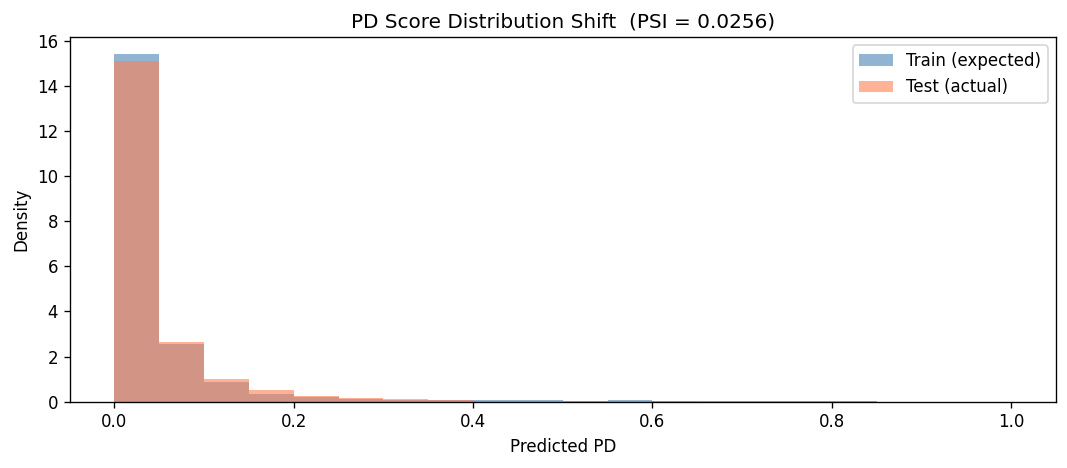

In [11]:
psi_result = psi(expected=y_prob_xgb_tr, actual=y_prob_xgb_te, n_bins=10)
print(f"PSI = {psi_result['psi']}  →  {psi_result['interpretation']}")
display(psi_result['bin_psi'])

fig, ax = plt.subplots(figsize=(9, 4))
bins = np.linspace(0, 1, 21)
ax.hist(y_prob_xgb_tr, bins=bins, alpha=0.6, label='Train (expected)', color='steelblue', density=True)
ax.hist(y_prob_xgb_te, bins=bins, alpha=0.6, label='Test (actual)',    color='coral',     density=True)
ax.set_title(f'PD Score Distribution Shift  (PSI = {psi_result["psi"]})')
ax.set_xlabel('Predicted PD'); ax.set_ylabel('Density'); ax.legend()
plt.tight_layout(); plt.show()

---
## 3. Threshold Analysis — Business Cost Table

In [12]:
tbl = threshold_analysis_table(
    y_true=y_def_te, y_prob=y_prob_xgb_te,
    thresholds=[0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50],
    cost_fn=1.0, cost_fp=5.0,
)
display(tbl)
cost_col = [c for c in tbl.columns if 'Business Cost' in c][0]
optimal_t = tbl.loc[tbl[cost_col].idxmin(), 'Threshold']
print(f'\nMinimum-cost threshold: {optimal_t}  |  F1-optimal threshold: {best_thresh:.3f}')

,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,False Positives (Good loans rejected),False Negatives (Bad loans approved),Business Cost (FP×5.0 + FN×1.0)
0,0.05,0.7444,0.0844,0.3968,0.1391,0.632,63243,8858,325073.0
1,0.10,0.8576,0.0970,0.2089,0.1325,0.632,28560,11617,154417.0
2,0.15,0.8994,0.1048,0.1236,0.1134,0.632,15504,12870,90390.0
3,0.20,0.9195,0.1115,0.0783,0.0920,0.632,9168,13535,59375.0
4,0.30,0.9366,0.1195,0.0342,0.0532,0.632,3698,14183,32673.0
5,0.40,0.9433,0.1325,0.0162,0.0289,0.632,1558,14447,22237.0
6,0.50,0.9459,0.1416,0.0077,0.0146,0.632,685,14572,17997.0



Minimum-cost threshold: 0.5  |  F1-optimal threshold: 0.051


---
## 4. SHAP Explainability

100%|===================| 282137/282138 [49:01<00:00]        /Users/MrinalGupta/Documents/Project/VS-Code Projects/credit-risk-modeling/notebooks/../src/evaluation.py:302: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Mean |SHAP|', y='Feature', data=top_df, palette=palette, ax=ax)


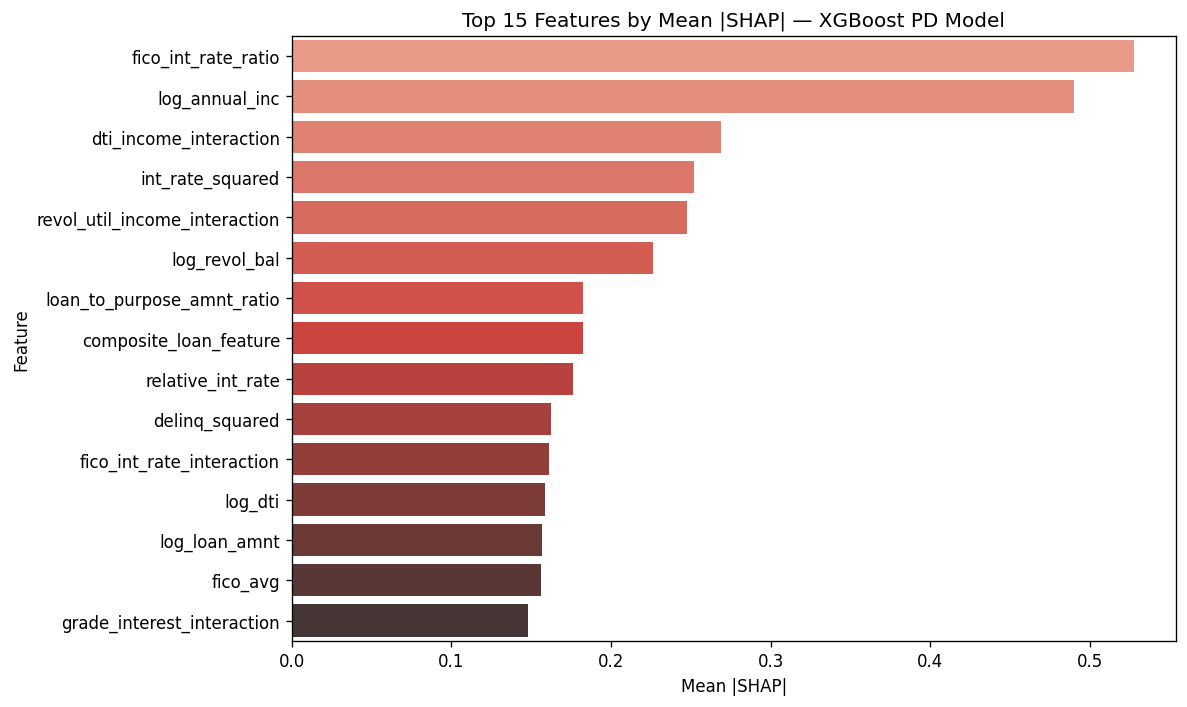

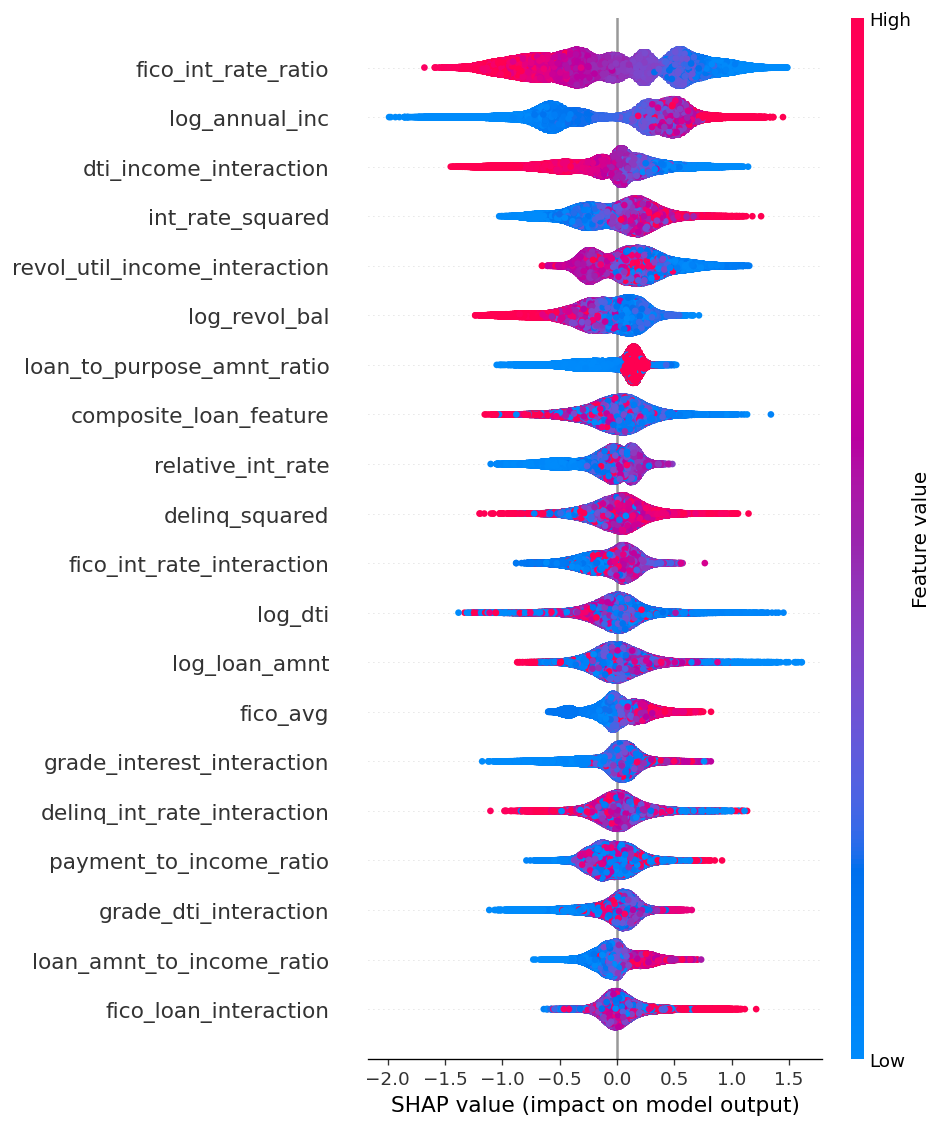

In [13]:
shap_values_xgb, top_xgb = shap_analysis(
    model=xgb_best, X_train=X_tr_dense, X_test=X_te_dense,
    feature_names=feature_names, model_name='XGBoost PD Model',
    palette='Reds_d', is_tree_based=True, top_n=15,
)

/Users/MrinalGupta/Documents/Project/VS-Code Projects/credit-risk-modeling/notebooks/../src/evaluation.py:302: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Mean |SHAP|', y='Feature', data=top_df, palette=palette, ax=ax)


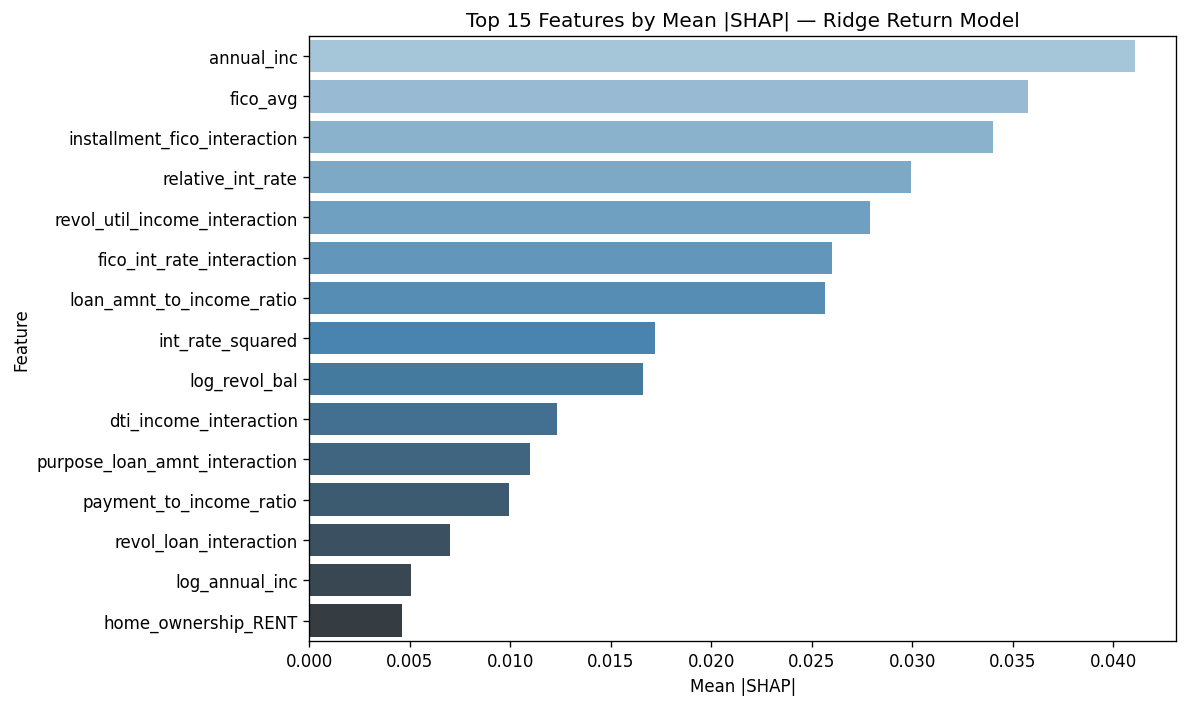

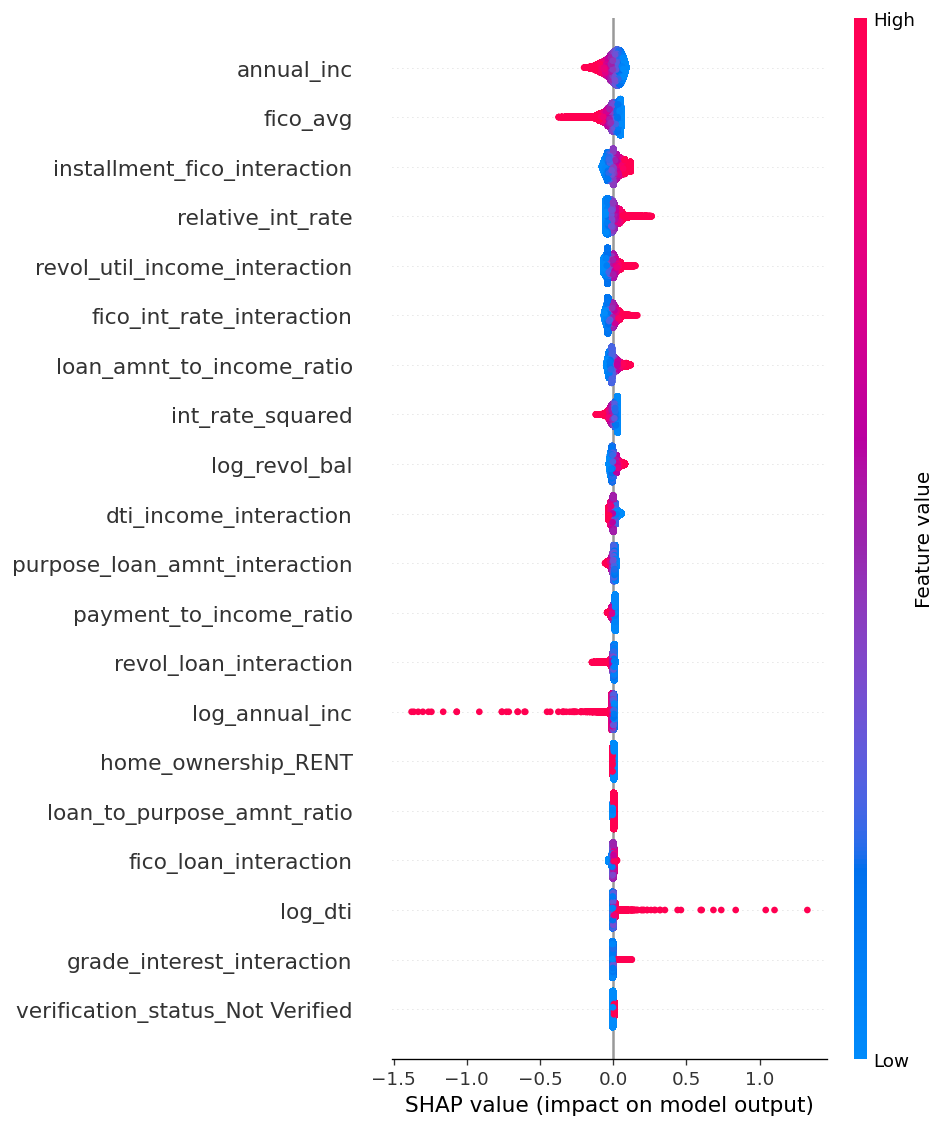

In [14]:
shap_values_ridge, top_ridge = shap_analysis(
    model=ridge_best, X_train=X_tr_dense, X_test=X_te_dense,
    feature_names=feature_names, model_name='Ridge Return Model',
    palette='Blues_d', is_tree_based=False, top_n=15,
)

In [15]:
common = set(top_xgb['Feature'].values) & set(top_ridge['Feature'].values)
print(f'Features in top-15 for both models ({len(common)}): {sorted(common)}')

Features in top-15 for both models (8): ['dti_income_interaction', 'fico_avg', 'fico_int_rate_interaction', 'int_rate_squared', 'log_annual_inc', 'log_revol_bal', 'relative_int_rate', 'revol_util_income_interaction']


---
## 5. Validation Summary

In [16]:
y_ret_pred = ridge_best.predict(X_te_t)
print('Model Validation Summary')
print('=' * 55)
print(f'XGBoost PD Model:')
print(f'  ROC-AUC (out-of-sample) : {roc_auc_score(y_def_te, y_prob_xgb_te):.4f}')
print(f'  KS Statistic            : {ks_result["ks_stat"]}  ({ks_result["interpretation"]})')
print(f'  PSI (train→test)        : {psi_result["psi"]}  ({psi_result["interpretation"]})')
print(f'  F1-optimal threshold    : {best_thresh:.3f}')
print(f'  Cost-optimal threshold  : {optimal_t}  (FP cost=5×, FN cost=1×)')
print(f'\nRidge Return Model:')
print(f'  R² (out-of-sample)      : {r2_score(y_ret_te, y_ret_pred):.4f}')
print()
print('Note: cost-optimal threshold (0.50) minimises 5×FP + 1×FN business cost.')
print('      F1-optimal threshold (0.113) maximises F1 — higher recall, lower precision.')

Model Validation Summary
XGBoost PD Model:
  ROC-AUC (out-of-sample) : 0.6320
  KS Statistic            : 0.1887  (Weak (KS < 0.20))
  PSI (train→test)        : 0.0256  (Stable (PSI < 0.10))
  F1-optimal threshold    : 0.051
  Cost-optimal threshold  : 0.5  (FP cost=5×, FN cost=1×)

Ridge Return Model:
  R² (out-of-sample)      : -0.0027

Note: cost-optimal threshold (0.50) minimises 5×FP + 1×FN business cost.
      F1-optimal threshold (0.113) maximises F1 — higher recall, lower precision.
